In [ ]:
import pandas as pd

df = pd.read_csv('ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = df.rename(columns={
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'wear',
    'Machine failure': 'failure'
})

In [ ]:
import pandas as pd

# 1. загрузка файла
df = pd.read_csv('ai4i2020.csv')

# 2. переименование колонок (чтобы было проще работать)
df = df.rename(columns={
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'wear',
    'Machine failure': 'failure'
})

# 3. быстрая проверка
print("\nПервые строки:")
print(df.head())

print("\nПропуски:")
print(df.isnull().sum())

# 4. сколько поломок
print("\nПоломки:")
print(df['failure'].value_counts())

print("\nПроцент поломок:")
print(df['failure'].mean() * 100)

# 5. главное — сравнение (исправленная версия)
print("\nСредние значения ПРИ поломке:\n",
      df[df['failure'] == 1].mean(numeric_only=True))

print("\nСредние значения БЕЗ поломки:\n",
      df[df['failure'] == 0].mean(numeric_only=True))


Первые строки:
   UDI Product ID Type  air_temp  process_temp  speed  torque  wear  failure  \
0    1     M14860    M     298.1         308.6   1551    42.8     0        0   
1    2     L47181    L     298.2         308.7   1408    46.3     3        0   
2    3     L47182    L     298.1         308.5   1498    49.4     5        0   
3    4     L47183    L     298.2         308.6   1433    39.5     7        0   
4    5     L47184    L     298.2         308.7   1408    40.0     9        0   

   TWF  HDF  PWF  OSF  RNF  
0    0    0    0    0    0  
1    0    0    0    0    0  
2    0    0    0    0    0  
3    0    0    0    0    0  
4    0    0    0    0    0  

Пропуски:
UDI             0
Product ID      0
Type            0
air_temp        0
process_temp    0
speed           0
torque          0
wear            0
failure         0
TWF             0
HDF             0
PWF             0
OSF             0
RNF             0
dtype: int64

Поломки:
failure
0    9661
1     339
Name: count, dt


Типы данных:
UDI               int64
Product ID       object
Type             object
air_temp        float64
process_temp    float64
speed             int64
torque          float64
wear              int64
failure           int64
TWF               int64
HDF               int64
PWF               int64
OSF               int64
RNF               int64
dtype: object

Пропуски:
UDI             0
Product ID      0
Type            0
air_temp        0
process_temp    0
speed           0
torque          0
wear            0
failure         0
TWF             0
HDF             0
PWF             0
OSF             0
RNF             0
dtype: int64

Баланс классов:
failure
0    9661
1     339
Name: count, dtype: int64

Процент поломок: 3.39%

=== Classification report ===
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg    

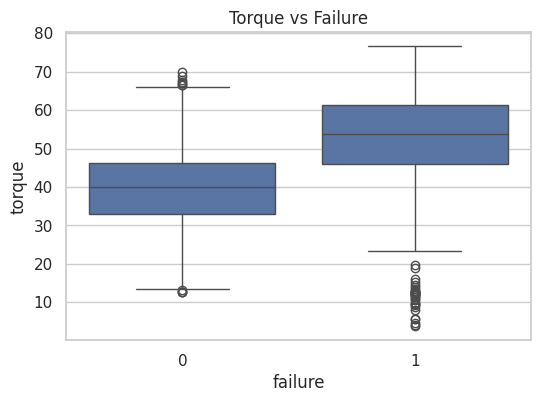

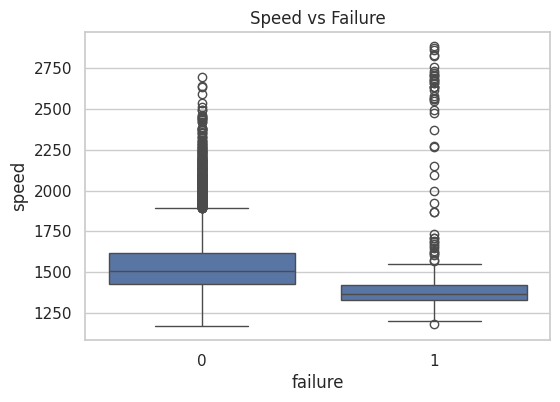

In [ ]:
# ===== 1. Импорт =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ===== 2. Загрузка данных =====
df = pd.read_csv('ai4i2020.csv')

# ===== 3. Переименование колонок =====
df = df.rename(columns={
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'wear',
    'Machine failure': 'failure'
})

# ===== 4. Быстрый анализ =====
print("\nТипы данных:")
print(df.dtypes)

print("\nПропуски:")
print(df.isnull().sum())

print("\nБаланс классов:")
print(df['failure'].value_counts())

failure_rate = df['failure'].mean() * 100
print(f"\nПроцент поломок: {failure_rate:.2f}%")

# ===== 5. Подготовка данных =====
X = df[['air_temp', 'process_temp', 'speed', 'torque', 'wear']]
y = df['failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # важно!
)

# ===== 6. Модель (исправляем imbalance) =====
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ===== 7. Оценка =====
print("\n=== Classification report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion matrix ===")
print(confusion_matrix(y_test, y_pred))

roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print(f"\nROC-AUC: {roc:.3f}")

# ===== 8. Важность признаков =====
importance = pd.Series(model.coef_[0], index=X.columns)

print("\n=== Feature importance ===")
print(importance.sort_values(ascending=False))

# ===== 9. Визуализация =====
plt.figure(figsize=(6,4))
sns.boxplot(x='failure', y='torque', data=df)
plt.title('Torque vs Failure')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='failure', y='speed', data=df)
plt.title('Speed vs Failure')
plt.show()

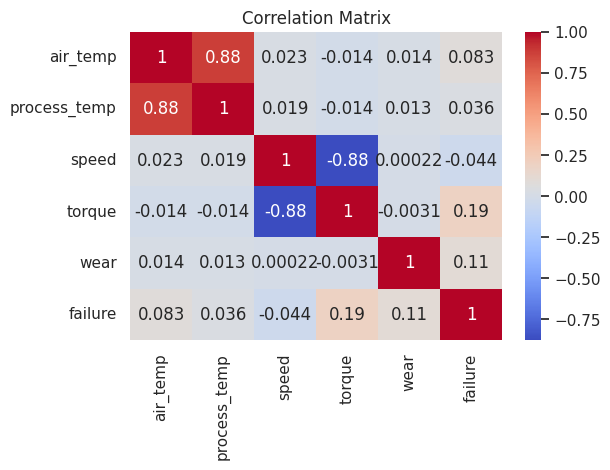

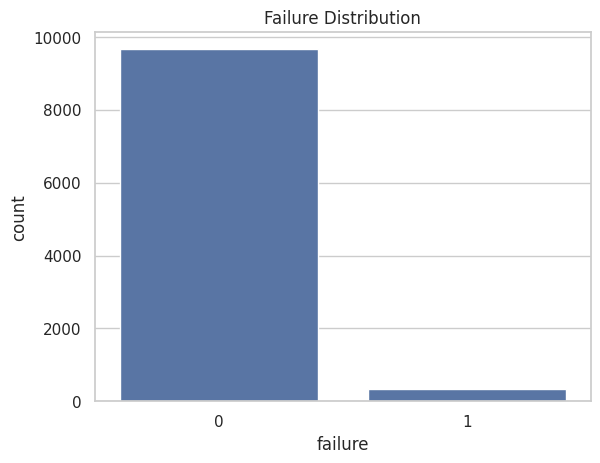


ВАЖНО:
В этой задаче важнее recall (найти поломки), чем accuracy.

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.57      0.70        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000


=== СРАВНЕНИЕ ===
Logistic Regression vs Random Forest

LogReg recall:               precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


RandomForest recall:               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.57      0.70        68

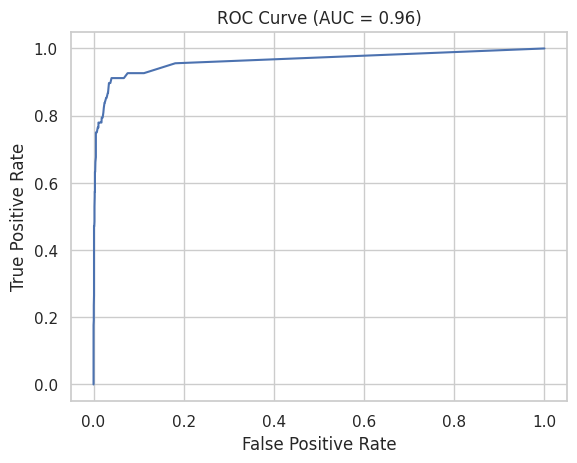

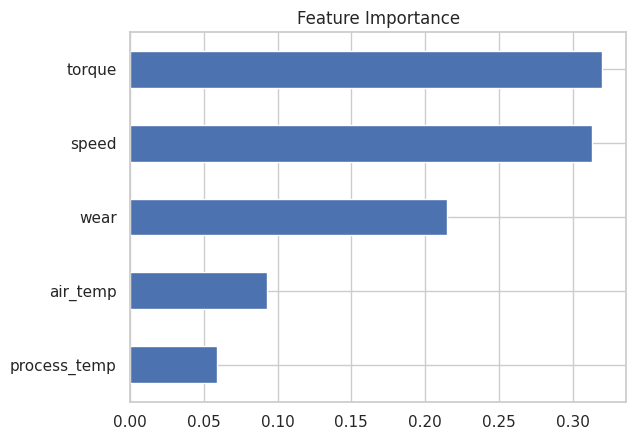


Модель склонна пропускать часть поломок (recall < 1), что может быть критично в реальной системе.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df[['air_temp','process_temp','speed','torque','wear','failure']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
sns.countplot(x='failure', data=df)
plt.title('Failure Distribution')
plt.show()
print("\nВАЖНО:")
print("В этой задаче важнее recall (найти поломки), чем accuracy.")
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("\n=== СРАВНЕНИЕ ===")
print("Logistic Regression vs Random Forest")

print("\nLogReg recall:", classification_report(y_test, y_pred))
print("\nRandomForest recall:", classification_report(y_test, y_pred_rf))
print("\n=== ВЫВОД ===")
print("""
Модель Random Forest показала лучший recall (0.57),
что важно для задачи предсказания поломок.

Accuracy высокая (0.98), но ключевая метрика — recall,
так как важно не пропускать поломки.

Наиболее важные признаки:
- температура (air_temp)
- крутящий момент (torque)

Модель может быть использована для раннего обнаружения отказов оборудования.
""")
print("\nДисбаланс классов сильно влияет на модель.")
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
from sklearn.metrics import roc_curve, auc
rf.fit(X_train, y_train)
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()
print("\nМодель склонна пропускать часть поломок (recall < 1), что может быть критично в реальной системе.")